# **STUDENT PERFORMANCE FACTORS**

## **Project Overview**
The goal of this study is to identify the variables that affect secondary school pupils' academic performance. We want to offer practical insights into how educational assistance and resources might be more effectively distributed to improve learning environments and increase student achievement by examining a wealth of data on student performance.

## **Research Objectives**

### 1. **Educational Resources and Academic Performance**
   - This study looks at how student performance is affected by having access to educational resources like **Internet availability** and **tutoring services**. Support initiatives may be directed by an understanding of these linkages, especially for students who might need more direction and materials.

### 2. **Socio-Economic Factors**
   - The study investigates the relationship between academic achievement and **socio-economic factors**, such as **parental education levels** and **family income**. We may learn more about educational inequalities and develop policies that support **equitable access** to academic opportunities for people from a variety of socioeconomic backgrounds by examining these characteristics.

### 3. **Personal Behavior and Lifestyle Choices**
   - Our study looks at how student performance is impacted by individual habits including **sleep duration** and **participation in extracurricular activities**. The results of this research can help create **wellness programs** and **individualized educational plans** that promote academic and personal development.

> These three objectives are answered through the two formal research questions defined later in the notebook: objective 2 (socio-economic factors) is Research Question 1, while objectives 1 and 3 (internet access, tutoring, sleep and extracurricular activities) are covered by Research Question 2, whose model includes all of these variables.

## **Machine Learning Goals**
   - This project's ultimate goal is to create a **Machine Learning (ML) model** that can estimate test scores, which are a measure of student achievement, depending on a variety of input inputs. In order to comprehend how combinations of these elements lead to academic performance, this model will offer a prediction framework.

Through this study, we hope to contribute to the development of balanced, encouraging learning environments for kids, assist policy-making initiatives to lessen educational disparities, and guide focused educational interventions.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('secondary_dataset.csv')
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
# Summary Statistics for all the Fields
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [4]:
# Fields in the Dataset
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

## **Feature Descriptions**

- **Hours_Studied**: The total hours a student spends studying in a typical week.
- **Attendance**: The percentage of classes attended by the student.
- **Parental_Involvement**: Level of parental engagement in the student's education, categorized as **Low**, **Medium**, or **High**.
- **Access_to_Resources**: Availability of educational resources to the student, rated as **Low**, **Medium**, or **High**.
- **Extracurricular_Activities**: Indicates whether the student participates in activities beyond the academic curriculum (**Yes**/**No**).
- **Sleep_Hours**: Average number of hours the student sleeps per night.
- **Previous_Scores**: The student’s scores from previous examinations.
- **Motivation_Level**: The student's self-reported level of motivation, categorized as **Low**, **Medium**, or **High**.
- **Internet_Access**: Indicates if the student has access to the internet at home (**Yes**/**No**).
- **Tutoring_Sessions**: Number of tutoring sessions attended by the student per month.
- **Family_Income**: The income level of the student's family, categorized as **Low**, **Medium**, or **High**.
- **Teacher_Quality**: Perceived quality of teaching, rated as **Low**, **Medium**, or **High**.
- **School_Type**: Type of school the student attends, e.g., **Public** or **Private**.
- **Peer_Influence**: The perceived influence of peers on the student's academic performance, described as **Positive**, **Negative**, or **Neutral**.
- **Physical_Activity**: Number of hours per week the student engages in physical activity.
- **Learning_Disabilities**: Indicates if the student has any reported learning disabilities (**Yes**/**No**).
- **Parental_Education_Level**: The highest level of education attained by the parents, such as **High School**, **College**, or **Postgraduate**.
- **Distance_from_Home**: The distance of the student's home from school, categorized as **Near**, **Moderate**, or **Far**.
- **Gender**: The gender of the student (**Male**/**Female**).
- **Exam_Score**: The score the student achieved on their most recent examination.


In [5]:
print(df.isna().sum().sum()) # total missing values
print(df.isna().sum()[df.isna().sum() > 0]) # missing values per column

235
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


In [6]:
# deleting rows with missing values
df = df.dropna()
print(df.isna().sum().sum())

df.shape # checking new shape of dataframe

0


(6378, 20)

**Handling missing values:** Missing values appear in only three categorical columns (Teacher_Quality: 78, Parental_Education_Level: 90, Distance_from_Home: 67). Dropping these rows removes 229 of 6,607 students (3.5%). Because the loss is small and the columns are categorical (so mean imputation is not meaningful), we drop the rows rather than impute them.

In [7]:
# Exam scores are out of 100, so anything above 100 is an invalid entry
print(df[df['Exam_Score'] > 100][['Exam_Score']])
df = df[df['Exam_Score'] <= 100]
df.shape

      Exam_Score
1525         101


(6377, 20)

**Invalid exam score:** One student has an `Exam_Score` of 101, which is impossible on a 100-point scale, so that row is removed as a data-entry error. The cleaned dataset used for the rest of the analysis has 6,377 students.

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 6377 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6377 non-null   int64
 1   Attendance                  6377 non-null   int64
 2   Parental_Involvement        6377 non-null   str  
 3   Access_to_Resources         6377 non-null   str  
 4   Extracurricular_Activities  6377 non-null   str  
 5   Sleep_Hours                 6377 non-null   int64
 6   Previous_Scores             6377 non-null   int64
 7   Motivation_Level            6377 non-null   str  
 8   Internet_Access             6377 non-null   str  
 9   Tutoring_Sessions           6377 non-null   int64
 10  Family_Income               6377 non-null   str  
 11  Teacher_Quality             6377 non-null   str  
 12  School_Type                 6377 non-null   str  
 13  Peer_Influence              6377 non-null   str  
 14  Physical_Activity       

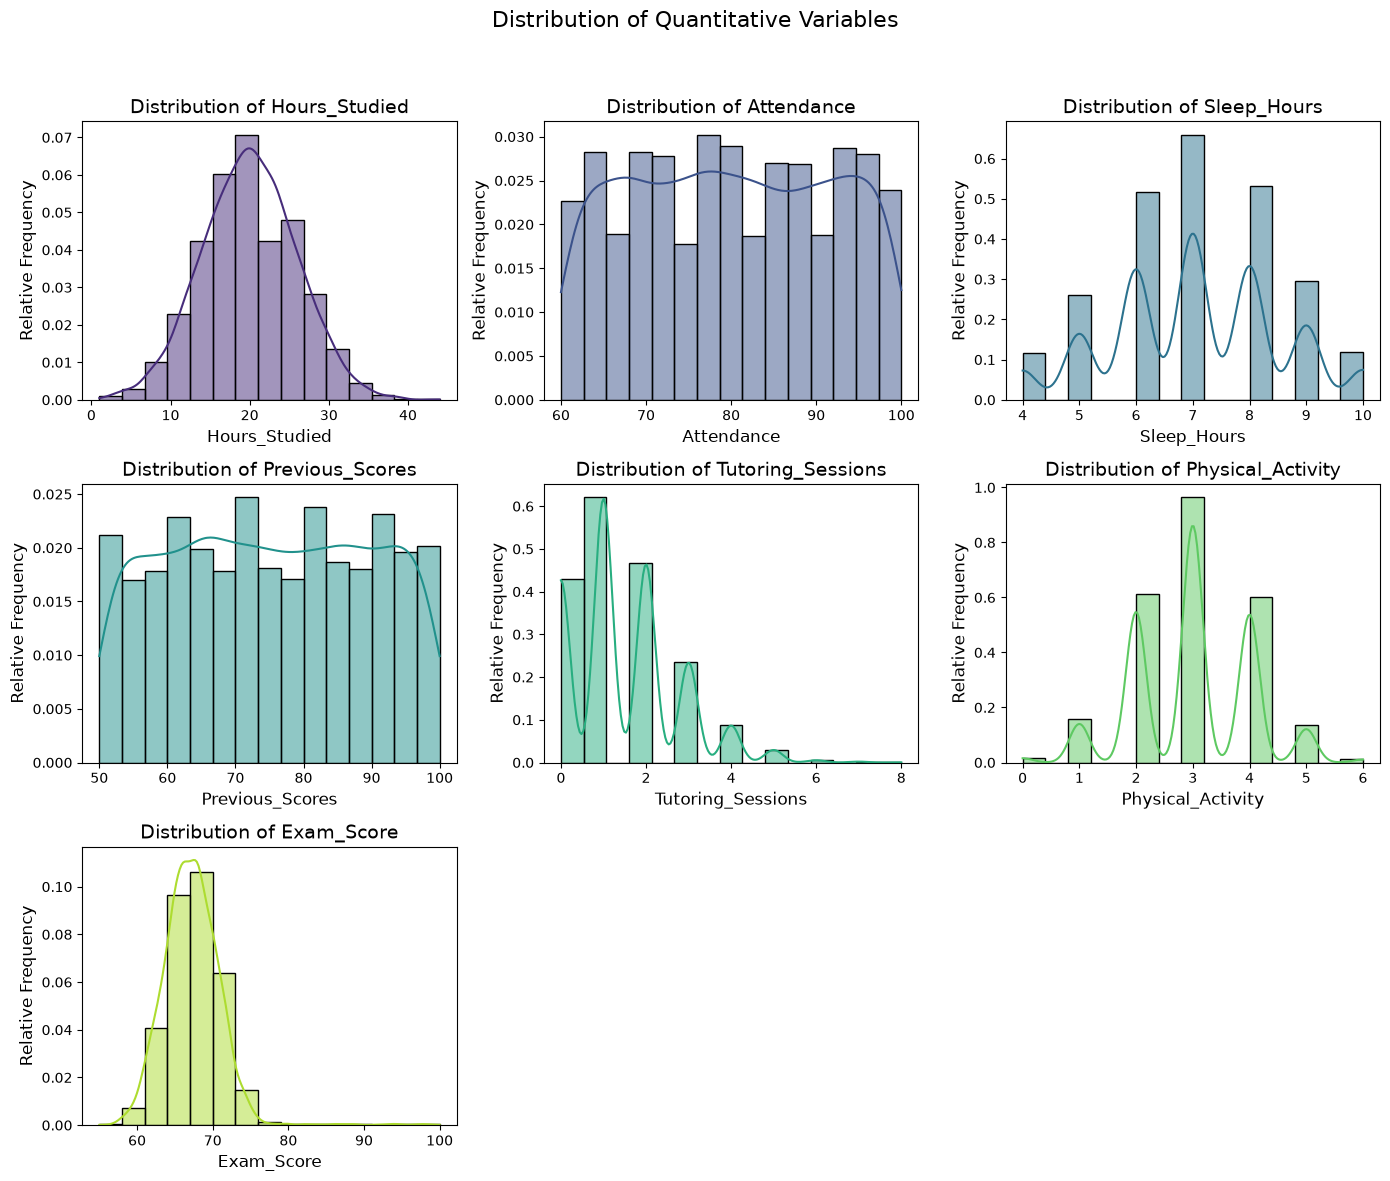

In [9]:
quant = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity','Exam_Score']

quant_palette = sns.color_palette("viridis", len(quant))

plt.figure(figsize=(14, 12))
for i, column in enumerate(quant, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[column], bins=15, kde=True, color=quant_palette[i-1], stat="density")
    plt.title(f'Distribution of {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Relative Frequency', fontsize=12)

plt.suptitle('Distribution of Quantitative Variables', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Hours_Studied:**
With a little amount of variance on each side, the figure indicates a distribution that is centered around 15–25 hours. This focus suggests that the majority of pupils study in a similar way, with few exceptions at different times. We may examine if this moderate range is associated with the best academic results thanks to this balanced distribution.

**Attendance:**
Attendance is spread roughly evenly between 60% and 100%, with no clear peak. Every attendance level in this range is well represented, and no student attends less than 60% of classes. This even spread makes it easy to compare outcomes across the whole attendance range.

**Sleep_Hours:**
The distribution peaks at 6 to 8 hours, which is how many hours most students sleep. The histogram's focused, limited range indicates that the majority of students have regular sleep schedules. In comparison to people who sleep more or less, this typical range of sleep could be used as a benchmark to investigate if this amount of sleep has a good or negative correlation with performance.

**Previous_Scores:**
Previous scores are spread roughly evenly between 50 and 100, with no strong peak. This contrasts with the final exam scores, which are tightly clustered, so prior results alone are unlikely to explain much of the variation in exam performance.

**Tutoring_Sessions:**
The majority of students attended zero to two tutoring sessions; after two sessions, the frequency sharply decreased. With only a tiny percentage of students attending more than two sessions, this skewed distribution indicates that tutoring is rather uncommon among students. Analyzing whether more tutoring is associated with improved test scores or other academic advantages may be made easier by the low attendance at tutoring sessions.

**Physical_Activity:**
Fewer pupils participate in more or less physical activities each week, whereas the majority do two to four. The distribution focuses on moderate physical activity, indicating that students engage in it frequently. Investigating whether moderate levels of physical activity are associated with better academic performance than those with low or high activity levels may be made easier with the help of this fundamental trend.

**Exam_Score:**
With a small surge in the middle, most students received scores in the 65–70 range. Scores above 80 and below 60 are less common. With fewer extremely low or high results, this pattern indicates that the majority of students receive medium to slightly above-average marks. This 65–70 clustering may be useful in determining the average performance level and the potential effects of other variables, such as attendance or study habits, on scores that fall or fall within this range.

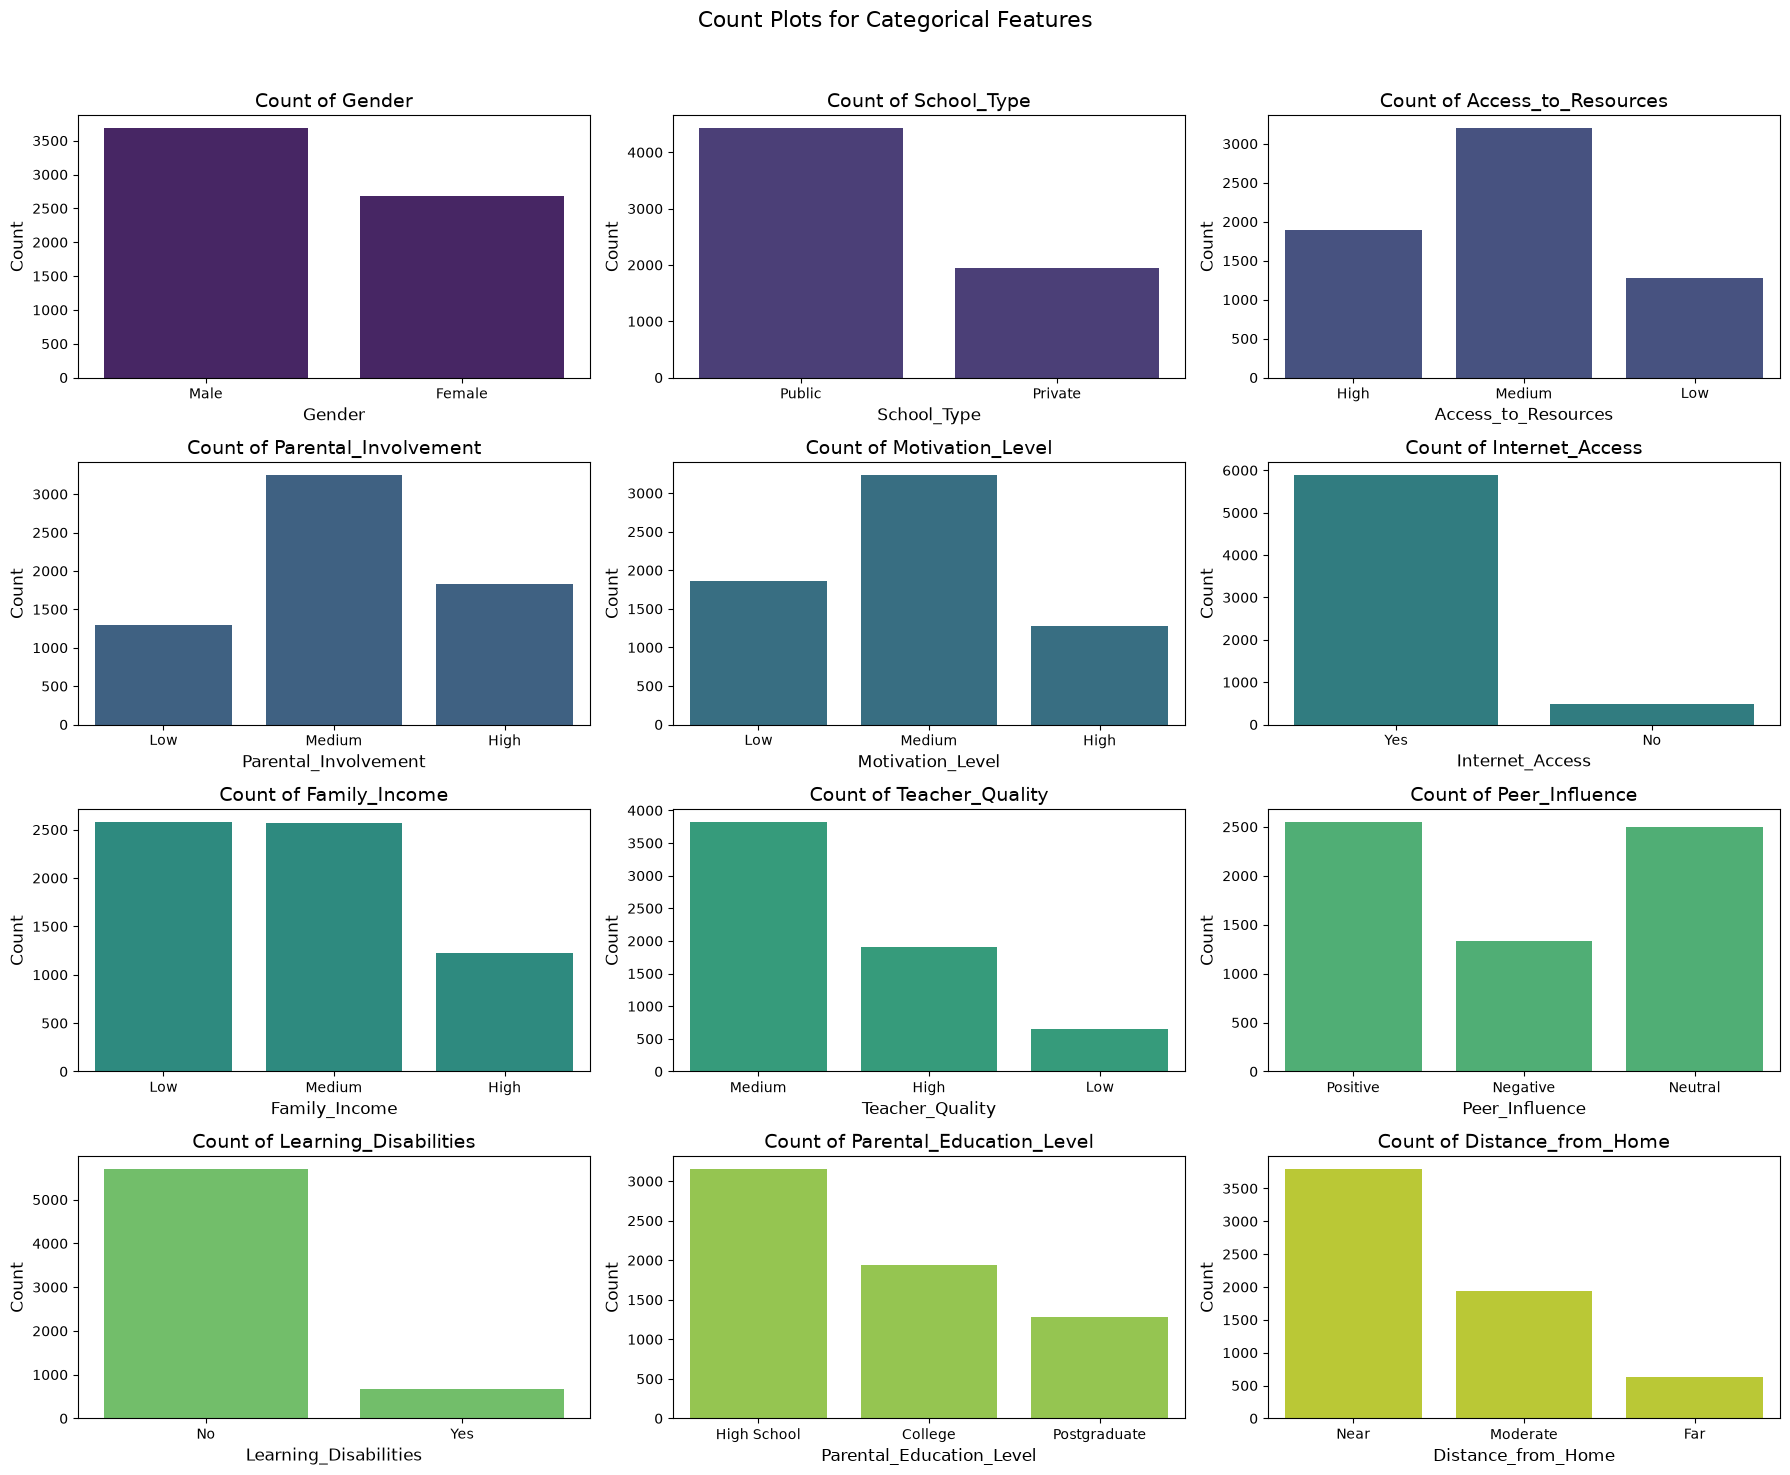

In [10]:
categorical = ['Gender', 'School_Type', 'Access_to_Resources', 'Parental_Involvement', 
                       'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 
                       'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 
                       'Distance_from_Home']

cat_palette = sns.color_palette("viridis", len(categorical))

plt.figure(figsize=(18, 15))
for i, column in enumerate(categorical, 1):
    plt.subplot(4, 3, i)
    sns.countplot(data=df, x=column, color=cat_palette[i-1])
    plt.title(f'Count of {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)

plt.suptitle('Count Plots for Categorical Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Gender:** More males than females (about 58% male, 42% female).

**School Type:** More students are in public schools than private.

**Access to Resources:** Most students have medium access, with fewer at high or low levels.

**Parental Involvement:** Moderate involvement is the most common, with fewer students reporting low or high involvement.

**Motivation Level:** Medium motivation is most frequent, followed by low and high.

**Internet Access:** The majority have internet access, with few lacking it.

**Family Income:** Low and medium income are almost equally common (about 40% each), with high income the least common (about 19%).

**Teacher Quality:** Mostly rated as medium, with fewer students rating it as high or low.

**Peer Influence:** Slightly more students report positive influence, with neutral and negative being less common.

**Learning Disabilities:** Most students do not report disabilities, with a small number indicating they have one.

**Parental Education Level:** Majority have parents with a high school education, followed by college and postgraduate.

**Distance from Home:** Most students live near their school, with fewer at moderate or far distances.

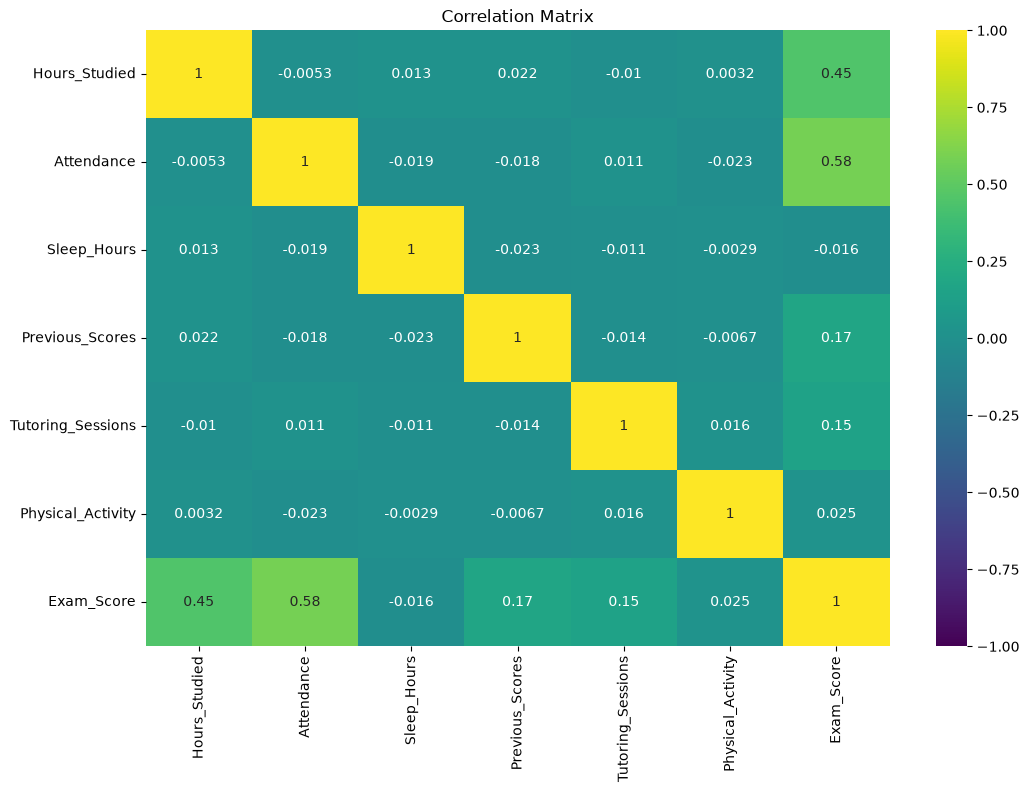

In [11]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

**Attendance and Exam_Score:**

Correlation Coefficient: 0.58, which is moderately strong.
This suggests that higher attendance correlates well with better exam performance, indicating that regular class attendance could positively impact learning and exam scores.

**Hours_Studied and Exam_Score:**

Correlation Coefficient: 0.45, showing a moderate positive correlation.
More study hours are associated with better exam scores, though the relationship is not as strong as attendance, implying that study efficiency might matter alongside study duration.

**Previous_Scores and Exam_Score:**

Correlation Coefficient: 0.17, a relatively weak positive correlation.
While there is some positive correlation between previous scores and exam scores, it’s weaker than expected. This could suggest variability in student performance over time or the influence of other factors on final scores.

**Tutoring_Sessions and Exam_Score:**

Correlation Coefficient: 0.16, indicating a weak positive correlation.
Tutoring sessions seem to have a minor positive impact, which might be more beneficial for specific students or subjects rather than showing a broad, significant impact.

**Sleep_Hours and Exam_Score:**

Correlation Coefficient: -0.02, essentially zero.
Sleep duration shows no relationship with exam performance in this dataset.

**Physical_Activity and Exam_Score:**

Correlation Coefficient: 0.025, essentially negligible.
On its own, physical activity shows almost no relationship with exam performance. (In the multiple regression later on, it has a small but statistically significant positive effect once other factors are held constant.)

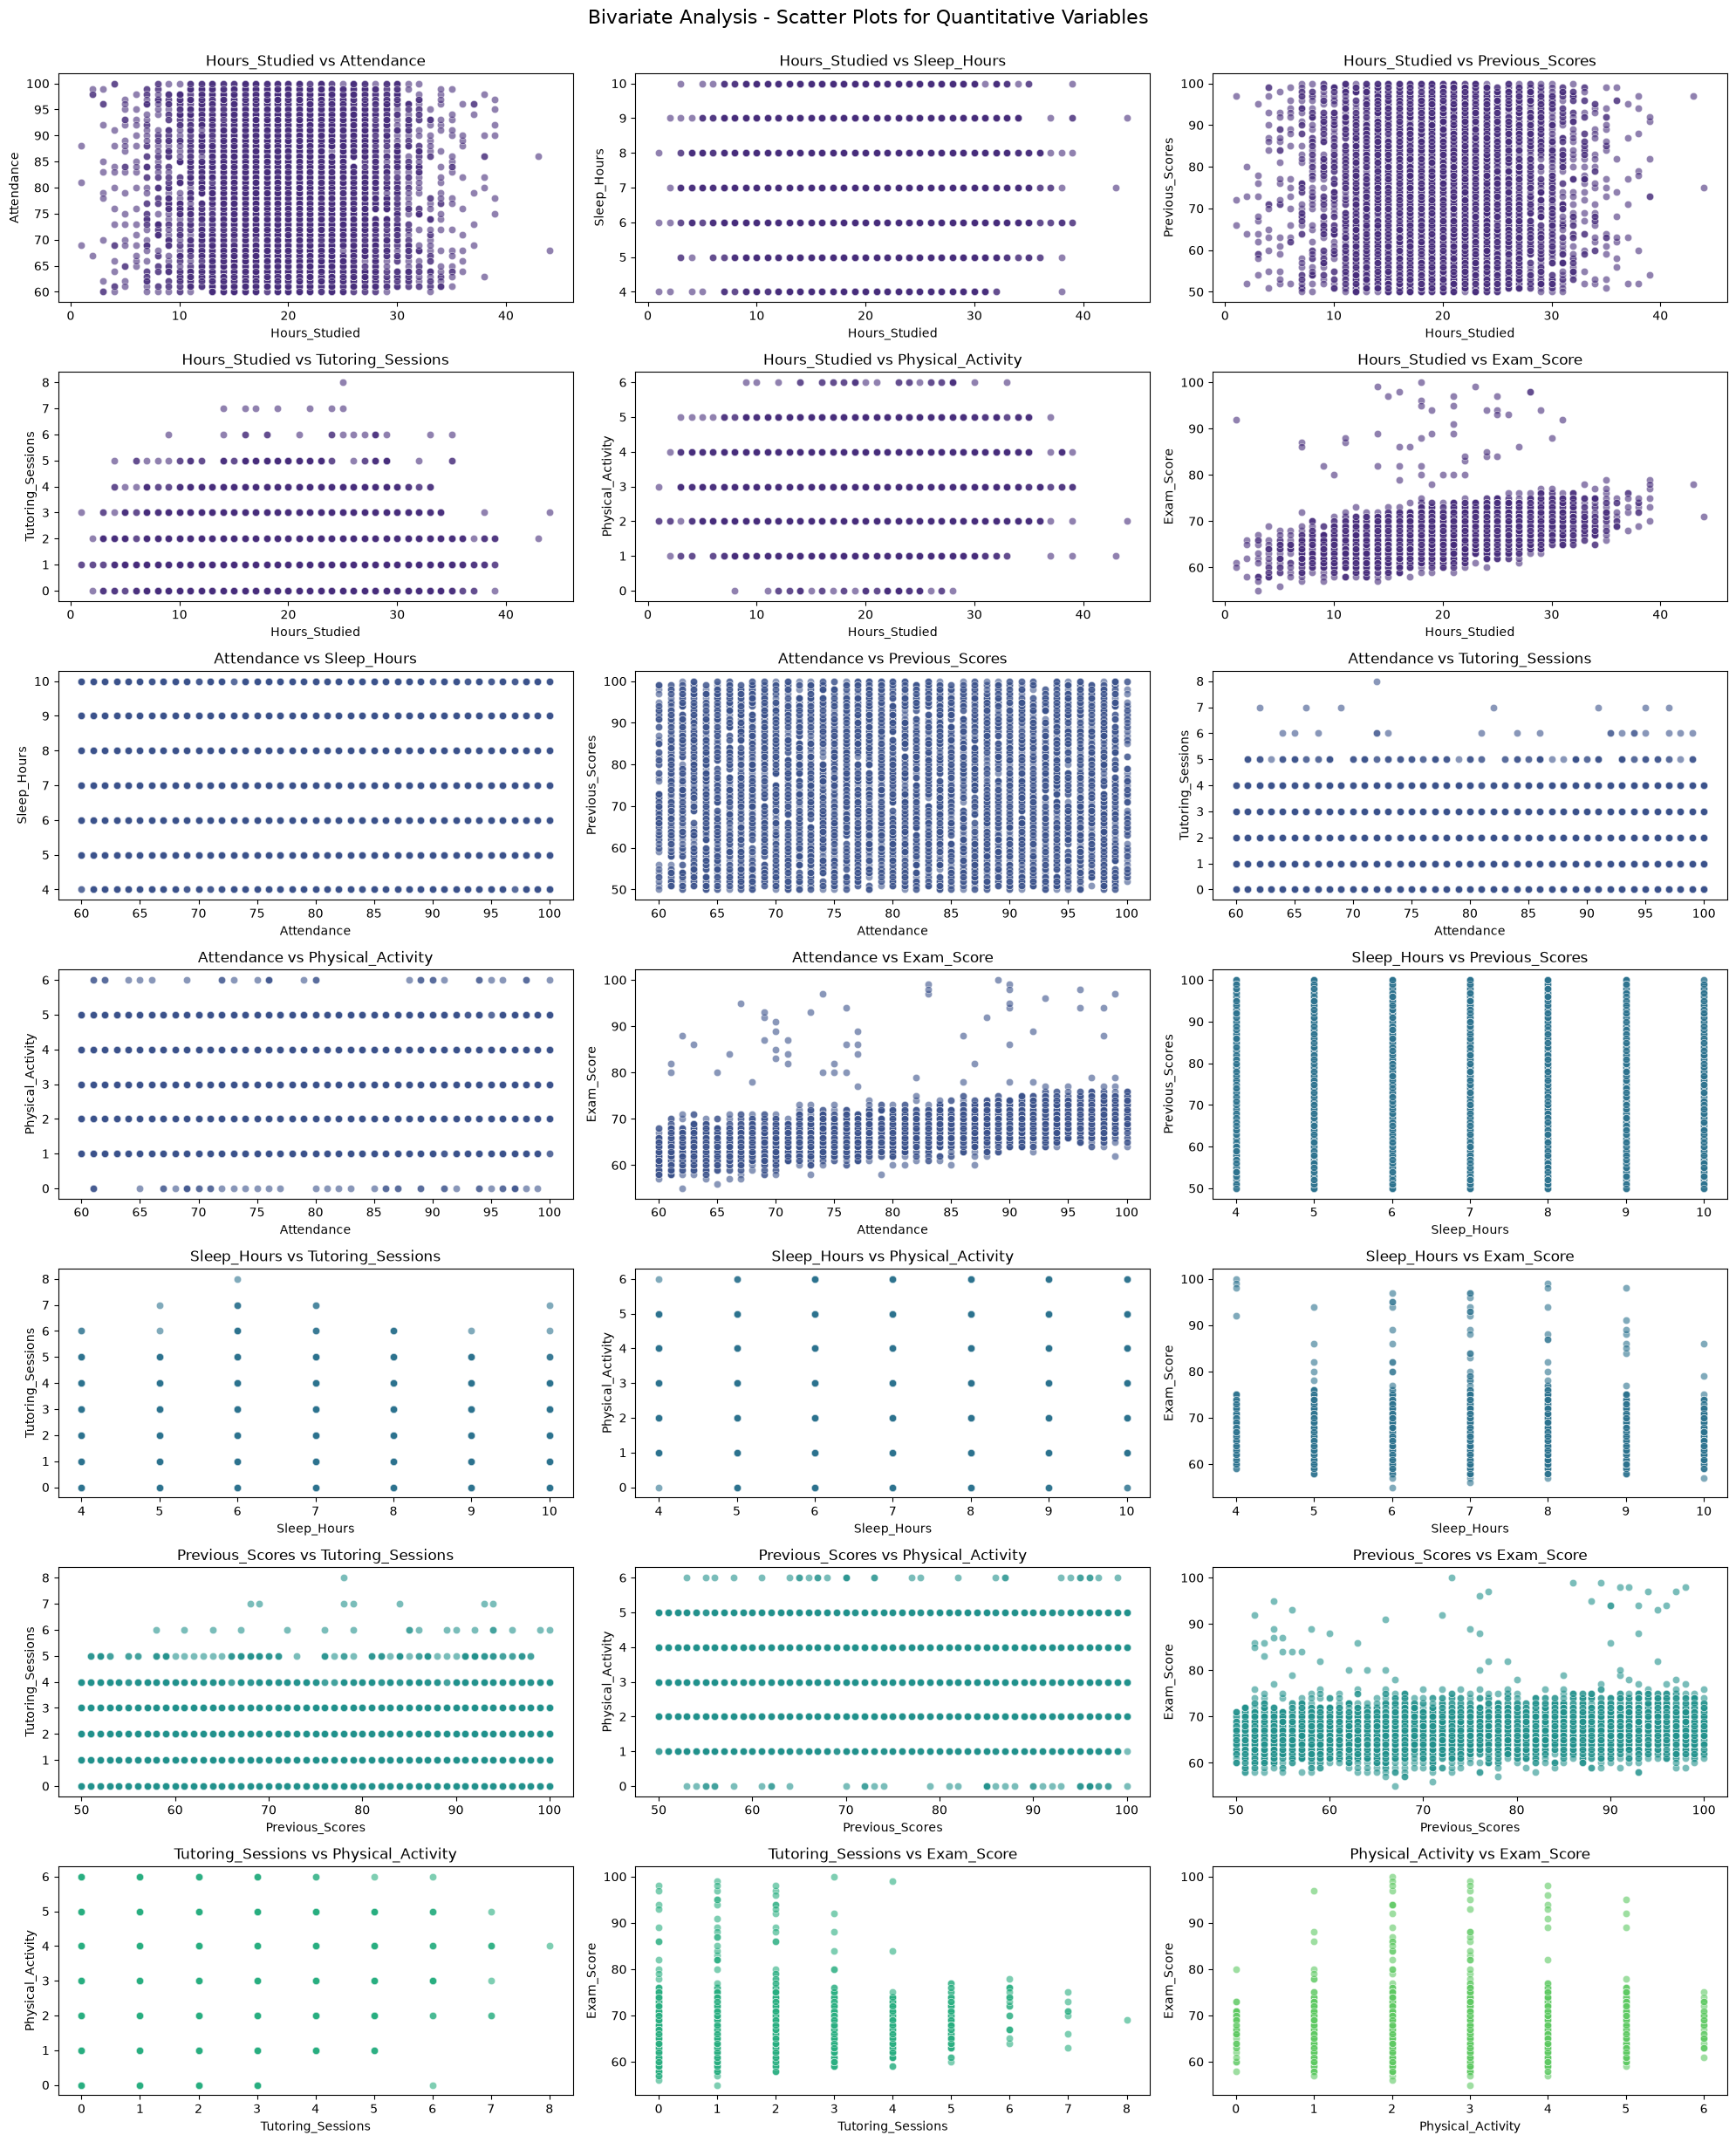

In [12]:
plt.figure(figsize=(20, 25))

plot_num = 1
for i in range(len(quant)):
    for j in range(i + 1, len(quant)):
        plt.subplot(7, 3, plot_num)
        sns.scatterplot(data=df, x=quant[i], y=quant[j], alpha=0.6, color=quant_palette[i])
        plt.xlabel(quant[i])
        plt.ylabel(quant[j])
        plt.title(f'{quant[i]} vs {quant[j]}')
        plot_num += 1

plt.suptitle("Bivariate Analysis - Scatter Plots for Quantitative Variables", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

The scatter plots show that attendance and study hours are the most important factors for academic performance. Better exam scores go with more study hours, and the trend continues steadily across the whole range (average scores rise from about 64 for students studying 10 hours or less to about 73 for those studying more than 35 hours). High attendance is also associated with better performance, indicating that consistent engagement promotes learning.

Prior scores show a weaker relationship with exam outcomes than study habits do. Tutoring sessions have a weak correlation with scores (r = 0.15), although average scores rise steadily with each additional session. All things considered, regular attendance and study habits are the strongest single indicators of a high exam score.

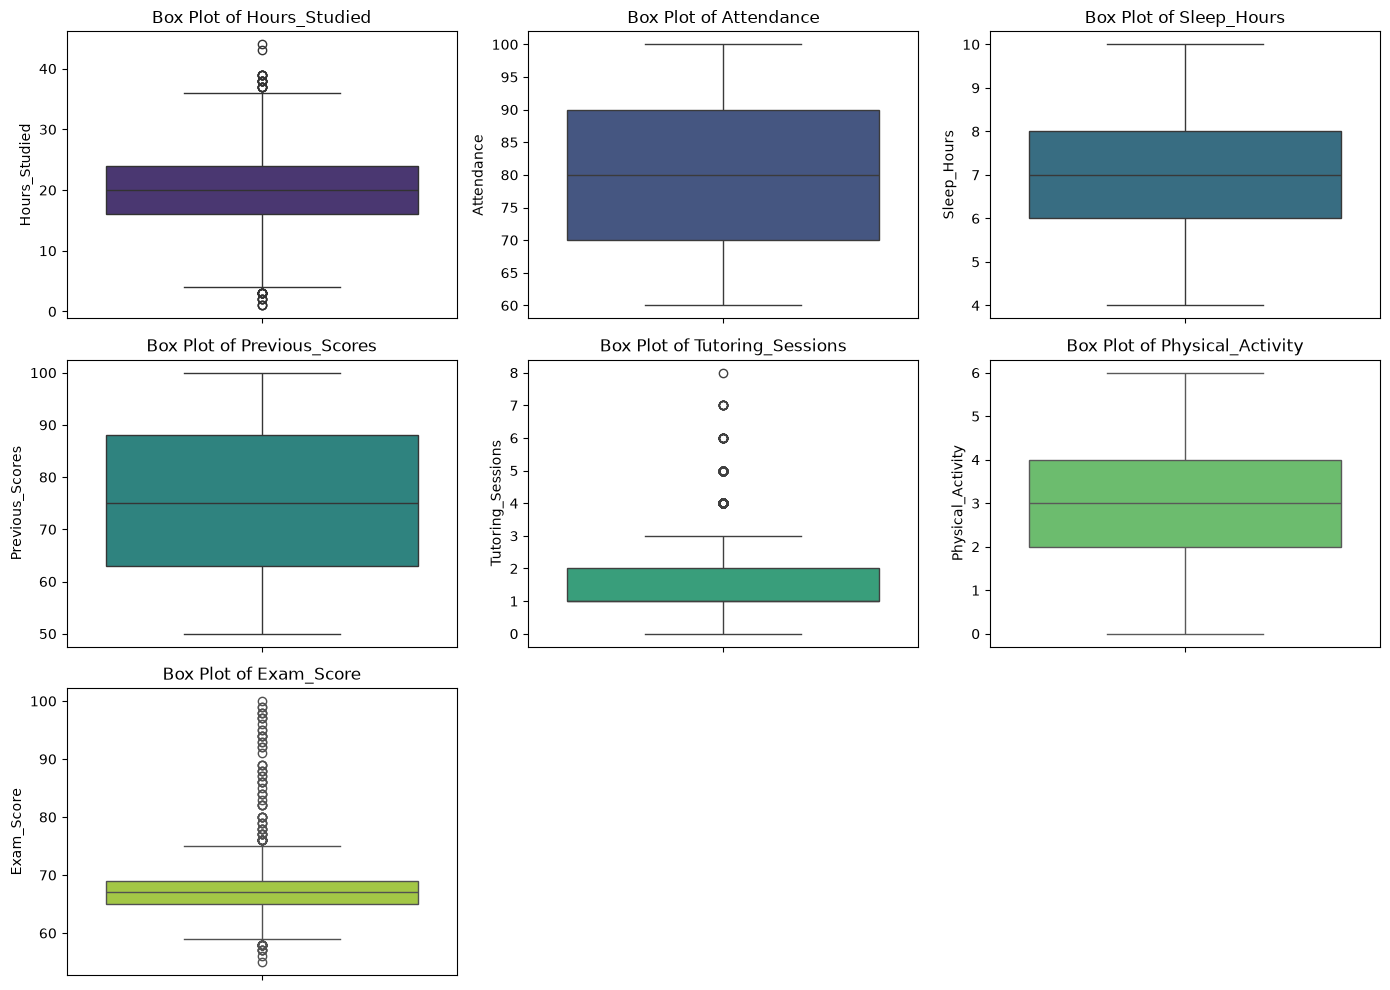

In [13]:
plt.figure(figsize=(14, 10))
for i, column in enumerate(quant, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(data=df, y=column, color=quant_palette[i-1])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)
plt.tight_layout()
plt.show()

**Hours_Studied:** The median is around 20 hours, with a few outliers above 36 hours and below 4 hours. Most students fall within the range of 10 to 30 hours.

**Attendance:** Most students have attendance rates between 70% and 90%, with a balanced spread and minimal outliers.

**Sleep_Hours:** The typical sleep range is between 6 to 8 hours, with few students sleeping less than 5 or more than 9 hours, showing no extreme outliers.

**Previous_Scores:** Scores are centered around 70-80, with a spread from 50 to 100, indicating a broad range of prior academic performance.

**Tutoring_Sessions:** Most students attended 0 to 2 sessions, with outliers at 4 or more sessions, showing limited tutoring involvement overall.

**Physical_Activity:** The range is mostly between 2 and 4 hours per week, with no notable outliers, indicating moderate activity levels.

**Exam_Score:** The scores are concentrated around 65-70, with several high outliers reaching above 80, suggesting a few exceptional performances.

In [14]:
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

for column in quant:
    outliers = find_outliers_iqr(df, column)
    print(f'{column} has {len(outliers)} outliers')

Hours_Studied has 40 outliers
Attendance has 0 outliers
Sleep_Hours has 0 outliers
Previous_Scores has 0 outliers
Tutoring_Sessions has 422 outliers
Physical_Activity has 0 outliers
Exam_Score has 102 outliers


**Handling outliers:** The outliers in `Hours_Studied` (for example 40+ hours a week) and `Tutoring_Sessions` (4 or more a month) are realistic values rather than errors, so they are kept. The `Exam_Score` outliers are unusually high scores (up to 100) that are also plausible, so they are kept as well. However, as the model diagnostics later show, these few unusually high scores are not explained by any of the recorded factors, and they account for most of the prediction error.

## **Research Questions**

### 1. **Impact of Parental and Socio-Economic Factors on Exam Performance**
   - **Research Question**: What is the effect of **parental involvement**, **access to resources**, **family income level**, and **parental education level** on student **exam performance (and, by proxy, overall student performance)**?
   - **Objective**: This question aims to explore how family support and socio-economic factors influence academic success. By analyzing these variables, we seek to understand the role of a student's home environment and resources in shaping educational outcomes. Insights could inform policies and practices to provide support where needed, addressing educational disparities.

### 2. **Combined Influence of Academic, Behavioral, and Environmental Factors on Exam Scores**
   - **Research Question**: How do various factors, including **hours studied**, **attendance**, **parental involvement**, **access to resources**, **extracurricular activities**, **sleep hours**, **previous academic performance**, **motivation level**, **internet access**, **tutoring sessions**, **family income**, **teacher quality**, **school type**, **peer influence**, **physical activity**, **learning disabilities**, **parental education level**, **distance from home**, and **gender**, collectively impact students' **exam scores (and by proxy, overall student performance)**?
   - **Objective**: This question broadens the scope to examine a holistic view of student performance, assessing how a combination of academic, behavioral, and environmental factors interact to affect outcomes. Understanding these interactions can help build predictive models for academic success and identify key areas for targeted interventions that support balanced student growth.


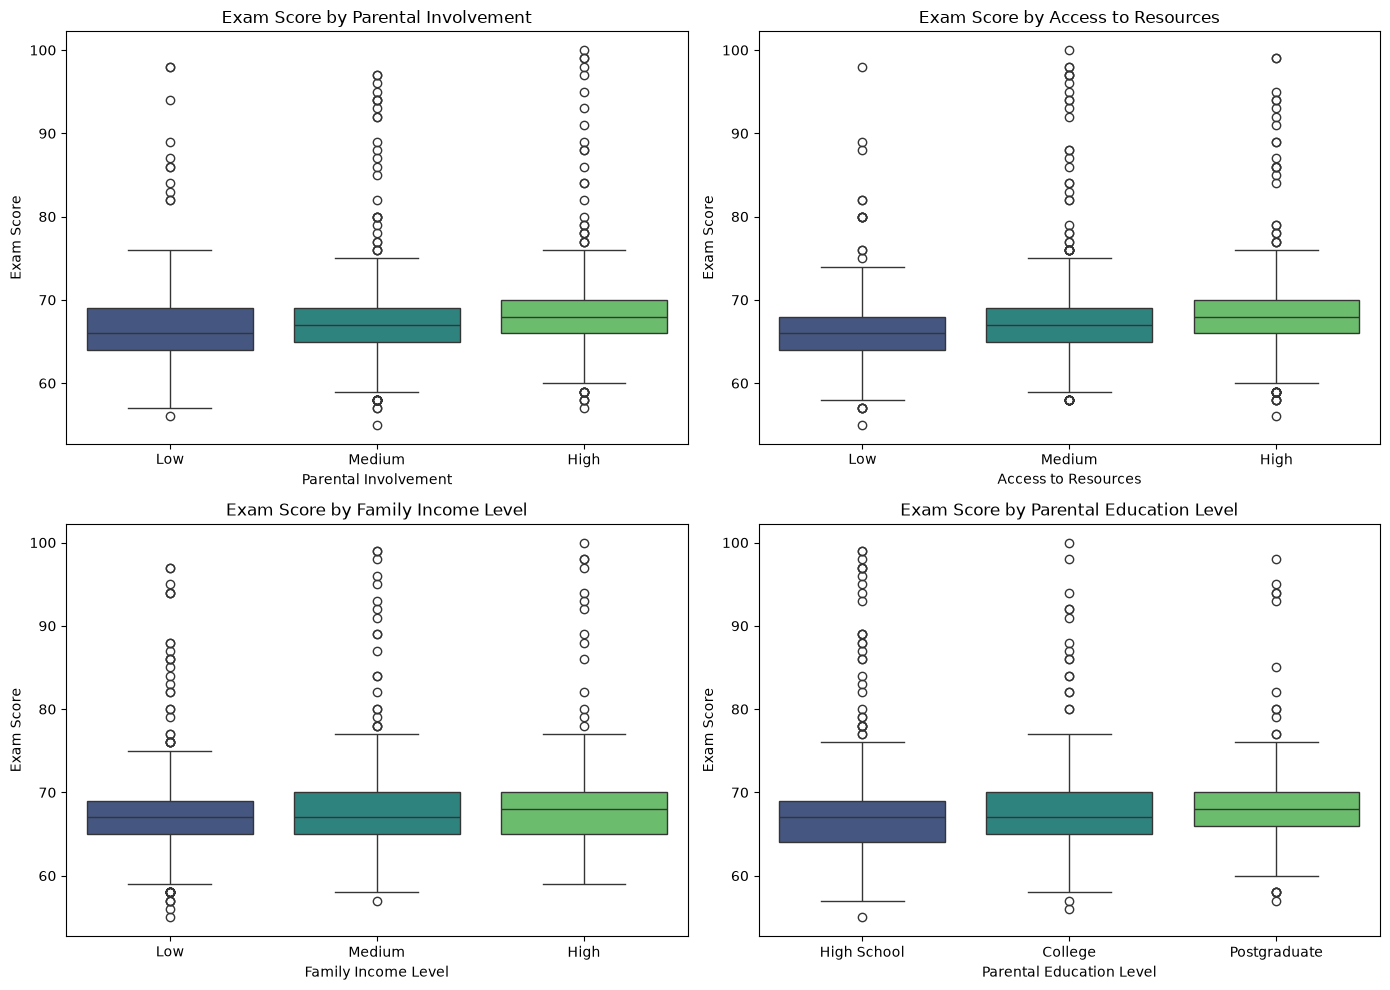

In [15]:
palette = sns.color_palette("viridis", 3)
level_order = ['Low', 'Medium', 'High']

plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='Parental_Involvement', y='Exam_Score', hue='Parental_Involvement', order=level_order, hue_order=level_order, palette=palette, legend=False)
plt.title('Exam Score by Parental Involvement')
plt.xlabel('Parental Involvement')
plt.ylabel('Exam Score')

plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Access_to_Resources', y='Exam_Score', hue='Access_to_Resources', order=level_order, hue_order=level_order, palette=palette, legend=False)
plt.title('Exam Score by Access to Resources')
plt.xlabel('Access to Resources')
plt.ylabel('Exam Score')

plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='Family_Income', y='Exam_Score', hue='Family_Income', order=level_order, hue_order=level_order, palette=palette, legend=False)
plt.title('Exam Score by Family Income Level')
plt.xlabel('Family Income Level')
plt.ylabel('Exam Score')

edu_order = ['High School', 'College', 'Postgraduate']
plt.subplot(2, 2, 4)
sns.boxplot(data=df, x='Parental_Education_Level', y='Exam_Score', hue='Parental_Education_Level', order=edu_order, hue_order=edu_order, palette=palette, legend=False)
plt.title('Exam Score by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()

In [16]:
# Mean exam score for each level of the socio-economic factors
for column in ['Parental_Involvement', 'Access_to_Resources', 'Family_Income', 'Parental_Education_Level']:
    print(df.groupby(column)['Exam_Score'].mean().round(2).sort_values(), '\n')

Parental_Involvement
Low       66.35
Medium    67.11
High      68.11
Name: Exam_Score, dtype: float64 

Access_to_Resources
Low       66.22
Medium    67.15
High      68.10
Name: Exam_Score, dtype: float64 

Family_Income
Low       66.85
Medium    67.37
High      67.81
Name: Exam_Score, dtype: float64 

Parental_Education_Level
High School     66.88
College         67.36
Postgraduate    67.97
Name: Exam_Score, dtype: float64 



**Parental Involvement:** Scores rise consistently with involvement (mean of about 66.4 for Low, 67.1 for Medium and 68.1 for High).

**Access to Resources:** Scores rise consistently with access (about 66.2 for Low, 67.2 for Medium and 68.1 for High), the largest gap among the four factors.

**Family Income:** Scores rise with income (about 66.9 for Low, 67.4 for Medium and 67.8 for High), although the gap is smaller than for involvement or resources.

**Parental Education Level:** Scores rise with parental education (about 66.9 for High School, 67.4 for College and 68.0 for Postgraduate).

For all four factors the differences between groups are small (1–2 points) compared with the overall spread of scores, but they are consistent in direction. The regression below tests whether they are statistically significant.

In [17]:
features = ['Parental_Involvement', 'Access_to_Resources', 'Family_Income', 'Parental_Education_Level']
X = pd.get_dummies(df[features], drop_first=True).astype(float)  # Convert categorical variables to dummy variables
y = df['Exam_Score'].astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.076
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     65.67
Date:                Wed, 30 Sep 2026   Prob (F-statistic):          5.85e-104
Time:                        23:23:53   Log-Likelihood:                -17461.
No. Observations:                6377   AIC:                         3.494e+04
Df Residuals:                    6368   BIC:                         3.500e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

## Dummy Variable Keys for Regression Interpretation

The regression model includes the following dummy variables for each categorical feature:

- **Parental_Involvement**:
  - `Parental_Involvement_Low`: 1 if Parental Involvement is Low, 0 otherwise
  - `Parental_Involvement_Medium`: 1 if Parental Involvement is Medium, 0 otherwise  
  - Baseline: **High** (The effect of "High" parental involvement is captured in the intercept)

- **Access_to_Resources**:
  - `Access_to_Resources_Low`: 1 if Access to Resources is Low, 0 otherwise
  - `Access_to_Resources_Medium`: 1 if Access to Resources is Medium, 0 otherwise  
  - Baseline: **High** (The effect of "High" access to resources is captured in the intercept)

- **Family_Income**:
  - `Family_Income_Low`: 1 if Family Income is Low, 0 otherwise
  - `Family_Income_Medium`: 1 if Family Income is Medium, 0 otherwise  
  - Baseline: **High** (The effect of "High" family income is captured in the intercept)

- **Parental_Education_Level**:
  - `Parental_Education_Level_High School`: 1 if Parental Education Level is High School, 0 otherwise
  - `Parental_Education_Level_Postgraduate`: 1 if Parental Education Level is Postgraduate, 0 otherwise  
  - Baseline: **College** (The effect of "College" education level is captured in the intercept)

### Notes
- **Intercept**: The intercept represents the expected `Exam_Score` when all categorical variables are at their baseline levels.
- **Coefficient Interpretation**: Each coefficient indicates the effect of a category relative to its baseline. For example, the coefficient for `Parental_Involvement_Low` shows how "Low" parental involvement differs from "High" parental involvement in terms of its effect on `Exam_Score`.


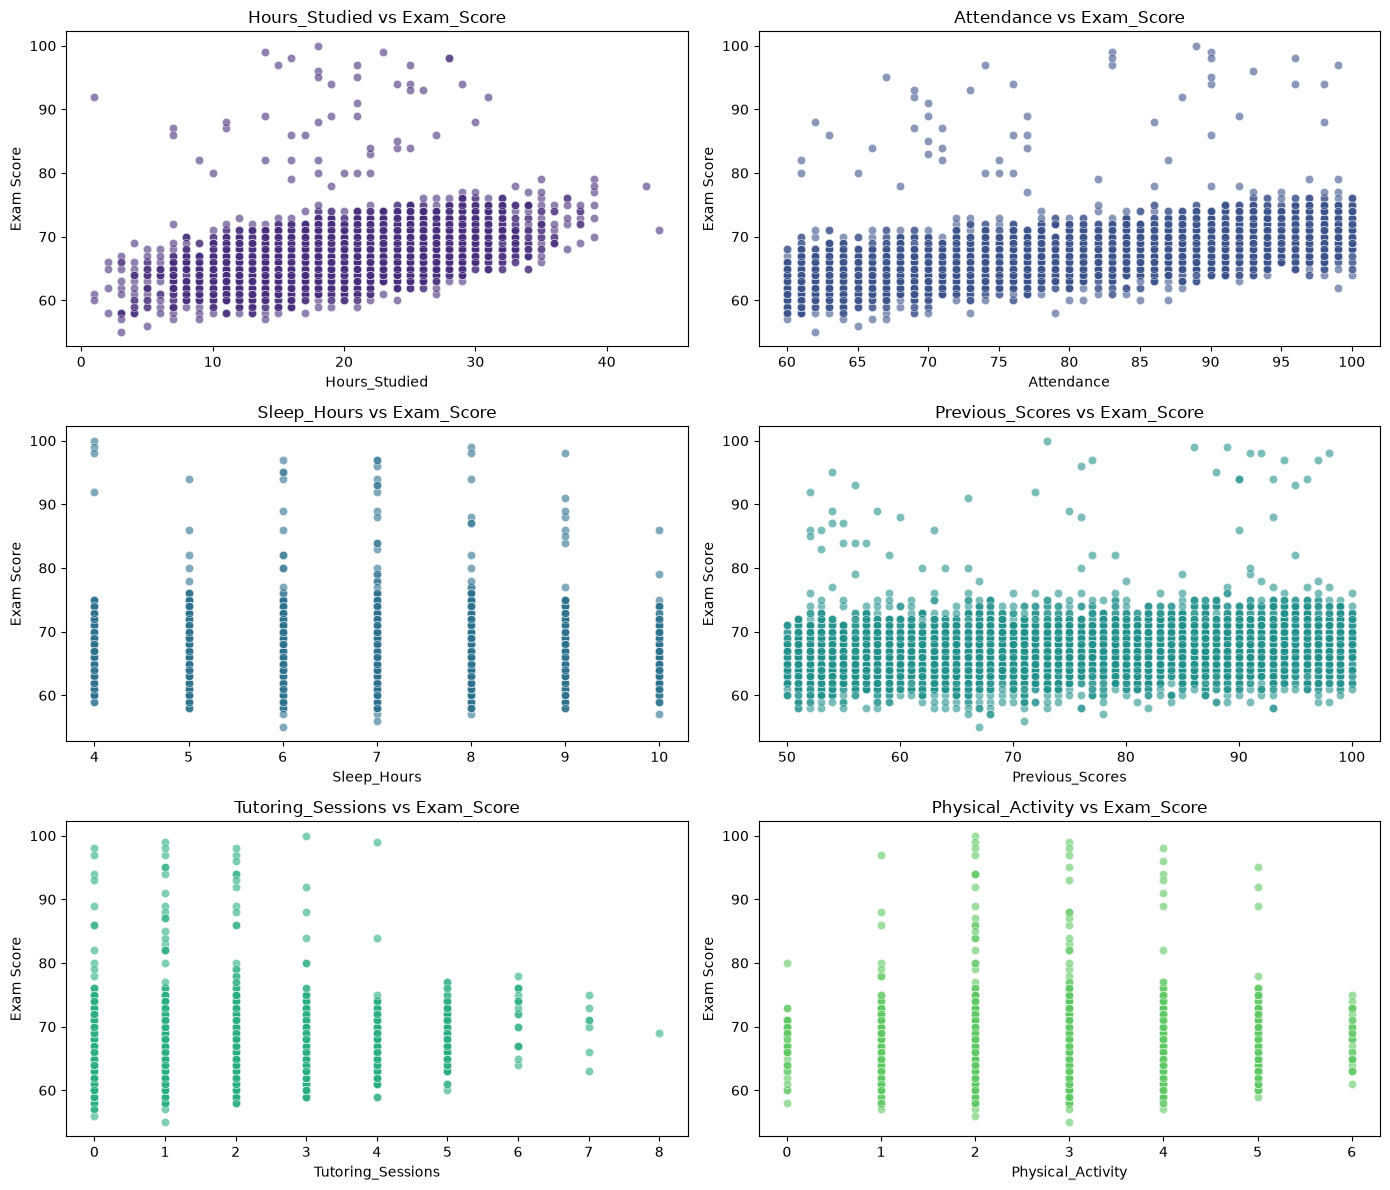

In [18]:
unaddressed_vars = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 
                    'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

plt.figure(figsize=(14, 12))

for i, column in enumerate(unaddressed_vars, 1):
    plt.subplot(3, 2, i)  
    sns.scatterplot(data=df, x=column, y='Exam_Score', alpha=0.6, color=quant_palette[i-1])
    plt.title(f'{column} vs Exam_Score')
    plt.xlabel(column)
    plt.ylabel('Exam Score')

plt.tight_layout()
plt.show()

**Hours Studied vs. Exam Score:** Positive trend; more study hours are associated with higher scores, and the trend continues steadily across the whole range.

**Attendance vs. Exam Score:** Positive trend; higher attendance correlates with higher scores, especially above 80% attendance.

**Sleep Hours vs. Exam Score:** Minimal correlation; exam scores do not vary significantly with sleep hours.

**Previous Scores vs. Exam Score:** Mild positive trend; higher previous scores slightly align with higher exam scores.

**Tutoring Sessions vs. Exam Score:** Weak correlation (r = 0.15), but average scores rise steadily with each additional session.

**Physical Activity vs. Exam Score:** Minimal correlation on its own (r = 0.03); any effect is only visible once other factors are controlled for in the regression.

In [19]:
features = [
    'Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources',
    'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level',
    'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
    'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level',
    'Distance_from_Home', 'Gender'
]

X = pd.get_dummies(df[features], drop_first=True).astype(float)
y = df['Exam_Score'].astype(float)

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Exam_Score   R-squared:                       0.726
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     622.4
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:23:53   Log-Likelihood:                -13588.
No. Observations:                6377   AIC:                         2.723e+04
Df Residuals:                    6349   BIC:                         2.742e+04
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [20]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Variance Inflation Factors to check for multicollinearity (constant excluded)
vif = pd.Series(
    [variance_inflation_factor(X.values, i) for i in range(1, X.shape[1])],
    index=X.columns[1:]
).sort_values(ascending=False)
print(vif.round(2))

Distance_from_Home_Near                  2.83
Distance_from_Home_Moderate              2.83
Family_Income_Medium                     1.85
Family_Income_Low                        1.85
Peer_Influence_Neutral                   1.76
Peer_Influence_Positive                  1.76
Motivation_Level_Low                     1.75
Motivation_Level_Medium                  1.75
Parental_Involvement_Low                 1.37
Parental_Involvement_Medium              1.36
Access_to_Resources_Medium               1.34
Access_to_Resources_Low                  1.34
Parental_Education_Level_High School     1.33
Parental_Education_Level_Postgraduate    1.33
Teacher_Quality_Low                      1.21
Teacher_Quality_Medium                   1.21
Physical_Activity                        1.01
Previous_Scores                          1.01
Attendance                               1.01
Extracurricular_Activities_Yes           1.00
School_Type_Public                       1.00
Internet_Access_Yes               

## OLS Regression Analysis Summary

- **Model fit**: Together, the predictors explain **72.6%** of the variation in exam scores (R-squared = 0.726). This is measured on the same data the model was fitted on; a fair out-of-sample comparison with the Random Forest follows below.
- **Strongest positive effects**: Hours_Studied (+0.29 points per weekly hour), Attendance (+0.20 points per percentage point), Tutoring_Sessions (+0.49 per monthly session), Peer_Influence_Positive (+1.02 vs. Negative), Internet_Access_Yes (+0.98).
- **Strongest negative effects**: Access_to_Resources_Low (−2.06 vs. High), Parental_Involvement_Low (−2.00 vs. High), Motivation_Level_Low (−1.08 vs. High), Family_Income_Low (−1.06 vs. High), Teacher_Quality_Low (−1.04 vs. High).
- **Smaller but significant effects**: Extracurricular_Activities_Yes (+0.56), Physical_Activity (+0.19 per weekly hour), Previous_Scores (+0.05 per point), Distance_from_Home_Near (+0.91 vs. Far), Learning_Disabilities_Yes (−0.85).
- **Not significant**: Sleep_Hours (p = 0.98), School_Type_Public (p = 0.63) and Gender_Male (p = 0.53).
- **Multicollinearity**: The condition number (1.49e+03) is high, but every Variance Inflation Factor is below 3, so multicollinearity is not a concern. The high condition number is due to the predictors being on very different scales (e.g. attendance in % vs. 0/1 dummy variables).
- **Non-normal residuals**: The Jarque-Bera test and the extreme skew (11.5) and kurtosis (141.6) show the residuals are not normally distributed. This is driven by a small number of students who scored much higher than the model predicts (see the diagnostics below). With 6,377 observations the coefficient estimates remain reliable, but individual p-values should be read with this in mind.

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

features_1 = ['Parental_Involvement', 'Access_to_Resources', 'Family_Income', 'Parental_Education_Level']

X_1 = pd.get_dummies(df[features_1], drop_first=True)
y = df['Exam_Score']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y, test_size=0.3, random_state=42)

rf_1 = RandomForestRegressor(random_state=69, n_estimators=100)
rf_1.fit(X_train_1, y_train_1)

y_pred_1 = rf_1.predict(X_test_1)

mae_1 = mean_absolute_error(y_test_1, y_pred_1)
r2_1 = r2_score(y_test_1, y_pred_1)

print(f"First Research Question (Random Forest):")
print(f"Mean Absolute Error (MAE): {mae_1}")
print(f"R-squared: {r2_1}")

First Research Question (Random Forest):
Mean Absolute Error (MAE): 2.6930598957164995
R-squared: 0.06119979981447832


In [22]:
features_2 = [
    'Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources',
    'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 
    'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
    'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level',
    'Distance_from_Home', 'Gender'
]

X_2 = pd.get_dummies(df[features_2], drop_first=True)

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y, test_size=0.3, random_state=42)

rf_2 = RandomForestRegressor(random_state=69, n_estimators=100)
rf_2.fit(X_train_2, y_train_2)

y_pred_2 = rf_2.predict(X_test_2)

mae_2 = mean_absolute_error(y_test_2, y_pred_2)
r2_2 = r2_score(y_test_2, y_pred_2)

print(f"Second Research Question (Random Forest):")
print(f"Mean Absolute Error (MAE): {mae_2}")
print(f"R-squared: {r2_2}")


Second Research Question (Random Forest):
Mean Absolute Error (MAE): 1.2116718913270639
R-squared: 0.6445756187199743


### Comparing against Linear Regression

The OLS R-squared reported above is measured on the same data the model was fitted on, while the Random Forest R-squared is measured on a held-out test set, so the two are not directly comparable. To compare the models fairly, we fit a linear regression on the same 70/30 split and also report 5-fold cross-validated R-squared for each model.

In [23]:
from sklearn.model_selection import cross_val_score

lr_1 = LinearRegression().fit(X_train_1, y_train_1)
lr_2 = LinearRegression().fit(X_train_2, y_train_2)

rows = []
for question, X_all, X_test, y_test, models in [
    ('Q1', X_1, X_test_1, y_test_1, {'Random Forest': rf_1, 'Linear Regression': lr_1}),
    ('Q2', X_2, X_test_2, y_test_2, {'Random Forest': rf_2, 'Linear Regression': lr_2}),
]:
    for name, fitted in models.items():
        y_pred = fitted.predict(X_test)
        cv_r2 = cross_val_score(fitted, X_all, y, cv=5, scoring='r2')
        rows.append({
            'Research Question': question,
            'Model': name,
            'Test MAE': mean_absolute_error(y_test, y_pred),
            'Test R-squared': r2_score(y_test, y_pred),
            'CV R-squared (5-fold)': cv_r2.mean(),
        })

comparison = pd.DataFrame(rows).round(3)
comparison

,Research Question,Model,Test MAE,Test R-squared,CV R-squared (5-fold)
0,Q1,Random Forest,2.693,0.061,0.062
1,Q1,Linear Regression,2.682,0.075,0.073
2,Q2,Random Forest,1.212,0.645,0.610
3,Q2,Linear Regression,0.456,0.773,0.725


In [24]:
# How much of the remaining error comes from a small number of students?
residuals = y_test_2 - lr_2.predict(X_test_2)
large = residuals.abs() >= 3

print(f"Test predictions within 1 point of the actual score: {(residuals.abs() < 1).mean():.1%}")
print(f"Test students with an error of 3+ points: {large.sum()} of {len(residuals)}")
print(f"Of those, scored higher than predicted: {(residuals[large] > 0).sum()}")
print(f"R-squared excluding those students: {r2_score(y_test_2[~large], lr_2.predict(X_test_2[~large])):.3f}")

Test predictions within 1 point of the actual score: 98.4%
Test students with an error of 3+ points: 11 of 1914
Of those, scored higher than predicted: 11
R-squared excluding those students: 0.985


**Model comparison:** For both research questions, **linear regression outperforms the Random Forest** on the same test set and in cross-validation. For Research Question 2, linear regression has a test MAE of 0.46 (vs. 1.21) and a test R-squared of 0.77 (vs. 0.64). For Research Question 1 both models perform poorly (R-squared of about 0.06–0.08), because the four socio-economic factors alone explain little of the variation in scores.

The diagnostics show why: the relationship between the factors and exam score is almost entirely linear and additive. 98.4% of the linear model's test predictions are within 1 point of the actual score. The remaining error comes almost entirely from 11 students (out of 1,914 in the test set) who all scored much higher than predicted; excluding them, R-squared rises to 0.985. These unusually high scores are not explained by any of the recorded factors. A Random Forest cannot represent a smooth linear trend as efficiently as a linear model, which is why it performs worse here.

First Research Question: Visualizing Results


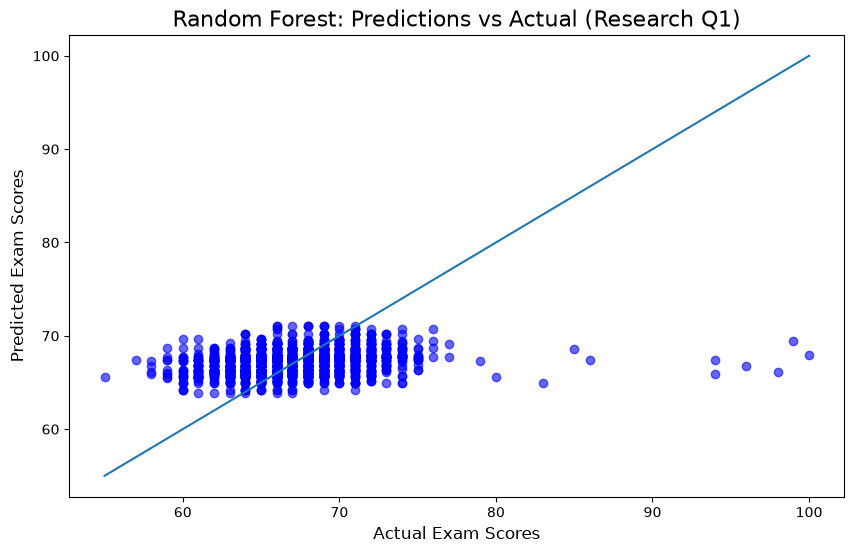

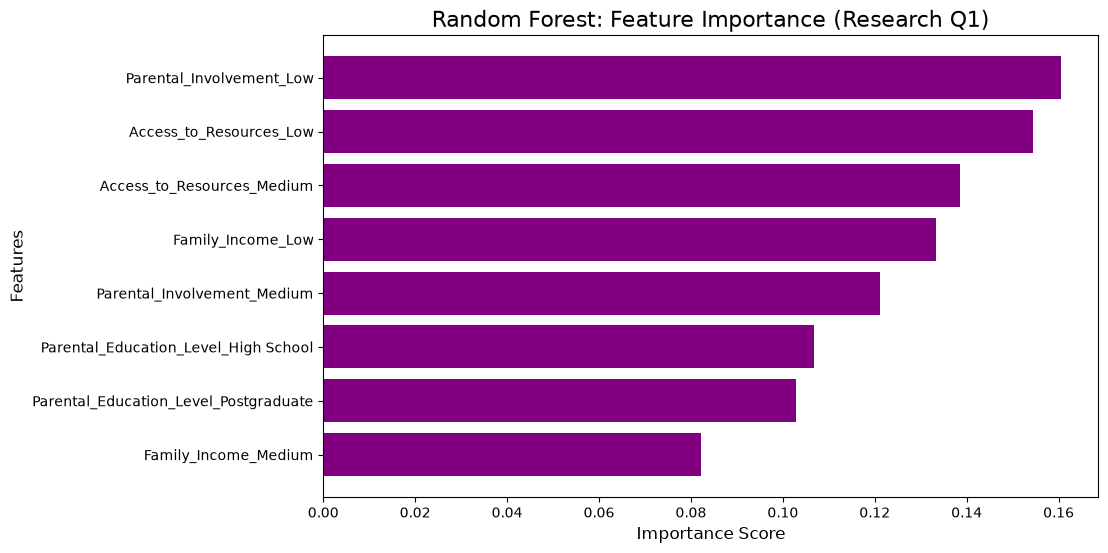

In [25]:
def plot_predictions(y_test, y_pred, title="Predictions vs Actual Values"):
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
    plt.title(title, fontsize=16)
    plt.xlabel("Actual Exam Scores", fontsize=12)
    plt.ylabel("Predicted Exam Scores", fontsize=12)
    plt.show()

def plot_feature_importance(model, feature_names, title="Feature Importance"):
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]  
    sorted_features = [feature_names[i] for i in indices]

    plt.figure(figsize=(10, 6))
    plt.barh(sorted_features[::-1], importances[indices][::-1], color='purple')
    plt.title(title, fontsize=16)
    plt.xlabel("Importance Score", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.show()

print("First Research Question: Visualizing Results")
plot_predictions(y_test_1, rf_1.predict(X_test_1), title="Random Forest: Predictions vs Actual (Research Q1)")
plot_feature_importance(rf_1, X_1.columns, title="Random Forest: Feature Importance (Research Q1)")

Second Research Question: Visualizing Results


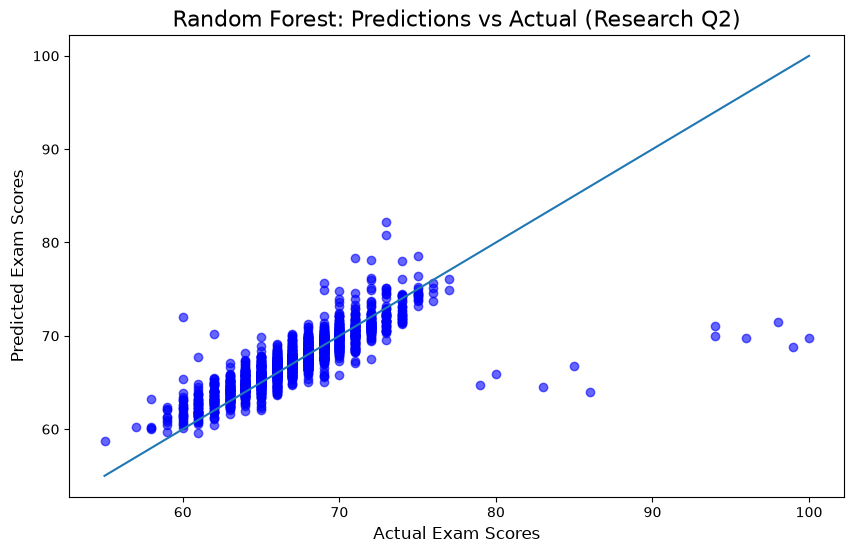

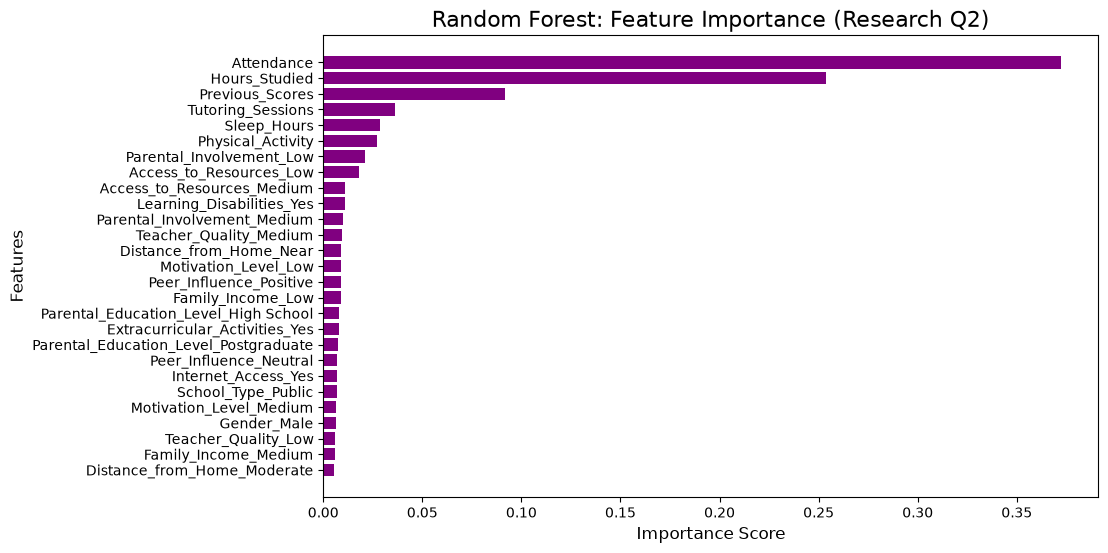

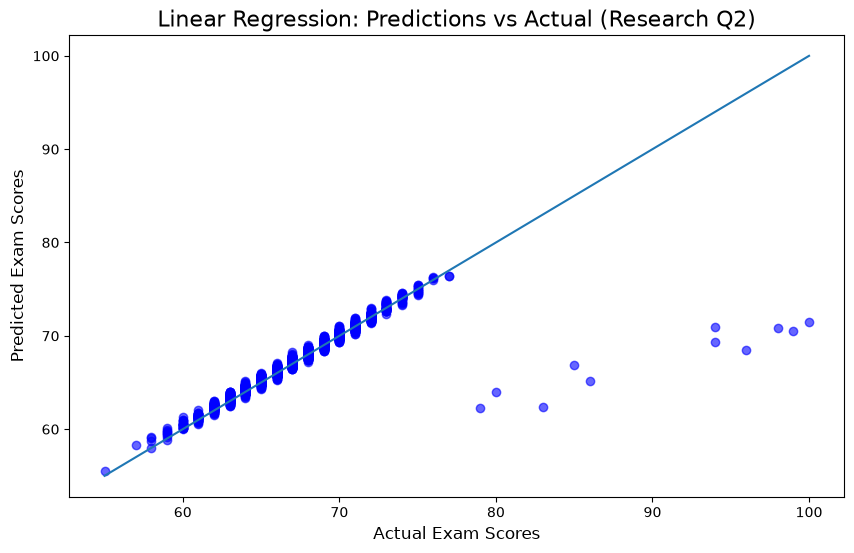

In [26]:
print("Second Research Question: Visualizing Results")
plot_predictions(y_test_2, rf_2.predict(X_test_2), title="Random Forest: Predictions vs Actual (Research Q2)")
plot_feature_importance(rf_2, X_2.columns, title="Random Forest: Feature Importance (Research Q2)")
plot_predictions(y_test_2, lr_2.predict(X_test_2), title="Linear Regression: Predictions vs Actual (Research Q2)")

### Interactive Predictors

The two forms below predict an exam score from the chosen inputs using the linear regression models, which performed best above. They need a running Jupyter kernel, so they are not interactive in the HTML export.

In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output

widget_model = lr_1  # best-performing model for Research Question 1

style = {'description_width': '150px'}
layout = widgets.Layout(width='80%')

parental_involvement = widgets.Dropdown(options=['Low', 'Medium', 'High'], description="Parental Involvement:", style=style, layout=layout)
access_to_resources = widgets.Dropdown(options=['Low', 'Medium', 'High'], description="Access to Resources:", style=style, layout=layout)
family_income = widgets.Dropdown(options=['Low', 'Medium', 'High'], description="Family Income:", style=style, layout=layout)
parental_education_level = widgets.Dropdown(options=['High School', 'College', 'Postgraduate'], description="Parental Education Level:", style=style, layout=layout)

predict_button = widgets.Button(description="Predict Exam Score", button_style='success', layout=widgets.Layout(width='40%'))

output = widgets.Output()

def predict_exam_score(b):
    with output:
        clear_output()
        input_data = pd.DataFrame({
            'Parental_Involvement': [parental_involvement.value],
            'Access_to_Resources': [access_to_resources.value],
            'Family_Income': [family_income.value],
            'Parental_Education_Level': [parental_education_level.value]
        })
        
        input_data_encoded = pd.get_dummies(input_data)
        all_columns = widget_model.feature_names_in_
        input_data_encoded = input_data_encoded.reindex(columns=all_columns, fill_value=0)
        
        prediction = widget_model.predict(input_data_encoded)
        
        display(widgets.HTML(f"<h3 style='color: green;'>The predicted Exam Score is: {prediction[0]:.2f}</h3>"))

predict_button.on_click(predict_exam_score)

form = widgets.VBox([
    parental_involvement, access_to_resources, family_income, parental_education_level, predict_button, output
])

display(form)

# Final Takeaways

## Research Question 1: Impact of Parental and Socio-Economic Factors on Exam Performance

The coefficients below come from the Research Question 1 OLS model (these four factors only). All are statistically significant (p ≤ 0.001).

### Summary of Findings
1. **Parental Involvement**: Lower levels of parental involvement are associated with lower exam performance.
   - Students with "Low" parental involvement scored, on average, B = 1.82 points lower than students with "High" involvement.
   - "Medium" involvement was associated with a smaller decrease (B = 1.02 points lower).

2. **Access to Resources**:
   - Students with "Low" access to resources scored B = 1.95 points lower than those with "High" access, the largest effect of the four factors.
   - Medium access was associated with a smaller decrease (B = 0.98 points lower).

3. **Family Income**:
   - Students from low-income families scored approximately B = 0.95 points lower than those from high-income families.
   - Medium-income families showed a smaller decrease (B = 0.43 points lower).

4. **Parental Education Level**:
   - Compared with students whose parents have a college education, those with postgraduate-educated parents scored higher (B = +0.64), while those whose parents had only a high school education scored lower (B = −0.47).

These effects remain similar in size when all other factors are controlled for in the Research Question 2 model (e.g. B = −2.00 for low parental involvement and B = −2.06 for low access to resources).

### Model Performance
| Model | Test MAE | Test R-squared | 5-fold CV R-squared |
|---|---|---|---|
| Linear Regression | 2.68 | 0.075 | 0.073 |
| Random Forest | 2.69 | 0.061 | 0.062 |

Both models have low predictive power: these four factors together explain only about 7% of the variation in exam scores, so the remaining variation must come from other factors.

### Implications
The effects are consistent and statistically significant, but modest in size: moving from the lowest to the highest level of any one factor corresponds to a difference of about 1–2 points. Parental involvement and access to resources matter most. Policy responses such as improving resource availability and supporting parental engagement for disadvantaged families may help, but on their own these factors are not strong predictors of an individual student's score.

In [28]:
style = {'description_width': '150px'}
layout = widgets.Layout(width='80%')

widget_model = lr_2  # best-performing model for Research Question 2

# Sliders are limited to the range seen in the data, since the models are not reliable outside it
def data_slider(column, description):
    return widgets.IntSlider(value=int(df[column].median()), min=int(df[column].min()), max=int(df[column].max()),
                             step=1, description=description, style=style, layout=layout)

hours_studied = data_slider("Hours_Studied", "Hours Studied:")
attendance = data_slider("Attendance", "Attendance:")
parental_involvement = widgets.Dropdown(options=['Low', 'Medium', 'High'], description="Parental Involvement:", style=style, layout=layout)
access_to_resources = widgets.Dropdown(options=['Low', 'Medium', 'High'], description="Access to Resources:", style=style, layout=layout)
extracurricular_activities = widgets.Dropdown(options=['Yes', 'No'], description="Extracurricular Activities:", style=style, layout=layout)
sleep_hours = data_slider("Sleep_Hours", "Sleep Hours:")
previous_scores = data_slider("Previous_Scores", "Previous Scores:")
motivation_level = widgets.Dropdown(options=['Low', 'Medium', 'High'], description="Motivation Level:", style=style, layout=layout)
internet_access = widgets.Dropdown(options=['Yes', 'No'], description="Internet Access:", style=style, layout=layout)
tutoring_sessions = data_slider("Tutoring_Sessions", "Tutoring Sessions:")
family_income = widgets.Dropdown(options=['Low', 'Medium', 'High'], description="Family Income:", style=style, layout=layout)
teacher_quality = widgets.Dropdown(options=['Low', 'Medium', 'High'], description="Teacher Quality:", style=style, layout=layout)
school_type = widgets.Dropdown(options=['Public', 'Private'], description="School Type:", style=style, layout=layout)
peer_influence = widgets.Dropdown(options=['Negative', 'Neutral', 'Positive'], description="Peer Influence:", style=style, layout=layout)
physical_activity = data_slider("Physical_Activity", "Physical Activity:")
learning_disabilities = widgets.Dropdown(options=['Yes', 'No'], description="Learning Disabilities:", style=style, layout=layout)
parental_education_level = widgets.Dropdown(options=['High School', 'College', 'Postgraduate'], description="Parental Education Level:", style=style, layout=layout)
distance_from_home = widgets.Dropdown(options=['Near', 'Moderate', 'Far'], description="Distance from Home:", style=style, layout=layout)
gender = widgets.Dropdown(options=['Male', 'Female'], description="Gender:", style=style, layout=layout)

predict_button = widgets.Button(description="Predict Exam Score", button_style='success', layout=widgets.Layout(width='40%'))

output = widgets.Output()

def predict_exam_score(b):
    with output:
        clear_output()
        input_data = pd.DataFrame({
            'Hours_Studied': [hours_studied.value],
            'Attendance': [attendance.value],
            'Parental_Involvement': [parental_involvement.value],
            'Access_to_Resources': [access_to_resources.value],
            'Extracurricular_Activities': [extracurricular_activities.value],
            'Sleep_Hours': [sleep_hours.value],
            'Previous_Scores': [previous_scores.value],
            'Motivation_Level': [motivation_level.value],
            'Internet_Access': [internet_access.value],
            'Tutoring_Sessions': [tutoring_sessions.value],
            'Family_Income': [family_income.value],
            'Teacher_Quality': [teacher_quality.value],
            'School_Type': [school_type.value],
            'Peer_Influence': [peer_influence.value],
            'Physical_Activity': [physical_activity.value],
            'Learning_Disabilities': [learning_disabilities.value],
            'Parental_Education_Level': [parental_education_level.value],
            'Distance_from_Home': [distance_from_home.value],
            'Gender': [gender.value]
        })
        
        input_data_encoded = pd.get_dummies(input_data)
        all_columns = widget_model.feature_names_in_
        input_data_encoded = input_data_encoded.reindex(columns=all_columns, fill_value=0)
        
        prediction = widget_model.predict(input_data_encoded)
        
        display(widgets.HTML(f"<h3 style='color: green;'>The predicted Exam Score is: {prediction[0]:.2f}</h3>"))

predict_button.on_click(predict_exam_score)

form = widgets.VBox([
    hours_studied, attendance, parental_involvement, access_to_resources, extracurricular_activities,
    sleep_hours, previous_scores, motivation_level, internet_access, tutoring_sessions,
    family_income, teacher_quality, school_type, peer_influence, physical_activity,
    learning_disabilities, parental_education_level, distance_from_home, gender, predict_button, output
])

display(form)

# Final Takeaways

## Research Question 2: Combined Influence of Academic, Behavioral, and Environmental Factors on Exam Scores

### Summary of Findings
1. **Attendance and Hours Studied**: These two factors are the strongest predictors of exam performance. They have the highest correlations with exam score (r = 0.58 and r = 0.45), the largest t-statistics in the regression, and the highest Random Forest feature importance.
   - **Attendance**: Each additional percentage point of attendance is associated with B = 0.20 more points; going from 60% to 100% attendance corresponds to about 8 points.
   - **Hours Studied**: Each additional weekly study hour is associated with B = 0.29 more points; studying 10 more hours a week corresponds to about 3 points.

2. **Tutoring Sessions and Previous Scores**:
   - **Tutoring Sessions**: Significant positive effect (B = 0.49 points per monthly session), even though its simple correlation with exam score is weak (r = 0.15).
   - **Previous Scores**: Small positive effect (B = 0.05 points per point of previous score).

3. **Home, School and Peer Factors**: Low access to resources (−2.06), low parental involvement (−2.00), low motivation (−1.08), low family income (−1.06), low teacher quality (−1.04) and a learning disability (−0.85) are all associated with lower scores, while positive peer influence (+1.02), internet access (+0.98) and living near the school (+0.91) are associated with higher scores.

4. **Lifestyle Factors**: Extracurricular activities (+0.56) and physical activity (+0.19 per weekly hour) have small positive effects. Sleep hours, school type and gender have no significant effect.

### Model Performance
| Model | Test MAE | Test R-squared | 5-fold CV R-squared |
|---|---|---|---|
| Linear Regression | 0.46 | 0.773 | 0.725 |
| Random Forest | 1.21 | 0.645 | 0.610 |

Linear regression is the better model: its predictions are typically within half a point of the actual score, and 98.4% of test predictions are within 1 point. Most of the remaining error comes from a small group of students who scored much higher than any of the recorded factors would predict.

### Implications
The analysis emphasizes the need for interventions that address attendance and study habits, alongside support such as tutoring, access to resources and parental engagement. Promoting extracurricular participation and a positive peer environment may also contribute to better outcomes.

## Conclusion

### Key Takeaways
1. **Significant Factors**:
   - Attendance and study hours are the most important predictors of academic success.
   - Access to resources and parental involvement have the largest effects among the socio-economic factors, each worth about 2 points between the lowest and highest levels.
   - Socio-economic factors matter, but on their own explain only about 7% of the variation in scores.
   - Sleep hours, school type and gender have no significant effect.

2. **Model Performance**:
   - Research Question 1 yielded low predictive power (R-squared ≈ 0.07) because it only considers four socio-economic factors.
   - Research Question 2 explains most of the variation in exam scores (test R-squared of 0.77 with linear regression).
   - Linear regression outperformed the Random Forest for both questions, showing that the factors combine in an essentially linear, additive way.

### Recommendations for Future Research
1. Investigate the small group of students who score far above what their recorded factors predict, since they account for most of the remaining prediction error. Additional variables such as stress levels, time management skills or test-taking ability may explain them.
2. Explore the role of teacher quality and peer influence in more depth, including possible interactions between factors (e.g. whether tutoring helps more when access to resources is low).
3. Validate the findings on other datasets, since the near-perfect linear fit suggests this dataset may not capture all the complexity of real student performance.

### Strengths and Limitations
- **Strengths**: Comprehensive analysis of multiple influencing factors, with fair model comparisons on held-out data and cross-validation, and actionable insights for policy-making and educational interventions.
- **Limitations**: The data is observational, so the results show associations rather than causal effects. Some variables, like sleep hours, showed no significant effect. Several factors (e.g. motivation, teacher quality, peer influence) are self-reported or perceived ratings. The residuals are non-normal due to a small number of unexplained high scores.

This study offers a foundational framework for understanding academic performance, with opportunities for deeper exploration in future iterations.